# Perform unfolding on EEG data from Stop-signal task with RidgeCV

In [ ]:
import pickle
import warnings
import os

import mne
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from himalaya.ridge import RidgeCV

# sys.path.insert(1, '../')
from basic_unfold_model import UnfoldModelPy
from models import models
import unfold_utils
import unfold_model

# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

Define picks

In [2]:
picks = [
    'Fp1',
    'AF3',
    'F7',
    'F3',
    'FC1',
    'FC5',
    'T7',
    'C3',
    'CP1',
    'CP5',
    'P7',
    'P3',
    'Pz',
    'PO3',
    'O1',
    'Oz',
    'O2',
    'PO4',
    'P4',
    'P8',
    'CP6',
    'CP2',
    'C4',
    'T8',
    'FC6',
    'FC2',
    'F4',
    'F8',
    'AF4',
    'Fp2',
    'Fz',
    'Cz',
]

## Read events and EEG data

In [3]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


## Perform RidgeCV unfolding

In [4]:
current_unfold_model = models.get_full_model()

In [5]:
for file_name in file_names[:1]:
    try:
        # read events dict
        with open(f'{events_data_dir}/{file_name}.pickle', 'rb') as handle:
            events = pickle.load(handle) # events dict channel_name:events_df
    
        # read EEG
        raw = mne.io.read_raw_brainvision(
            f'{eeg_data_dir}/{file_name}.vhdr',
            preload=True,
            eog=('HEOG', 'VEOG'),
        ).pick(picks=picks)
    
        # perform unfolding separately for each channel
        # channels = raw.info['ch_names']
        channels = ['Fz']
        results_channels = dict()
        for channel in channels:
            channel_events_df = events[channel]
            # clear bad segments
            channel_events_df = channel_events_df[channel_events_df['bad'] == False]
            # get EEG data
            eeg_data = raw.get_data(picks=channel)
            # cast EEG data from V to uV
            eeg_data = eeg_data * 1000000
            
            model = UnfoldModelPy(
                u_model = current_unfold_model,
            )
            model.fit(eeg_data, channel_events_df)
            predicted_raw_train = model.predict(signal=eeg_data, events_df=channel_events_df)

            results_channel_df = model.get_results(predicted=True, signal=eeg_data, events_df=channel_events_df)
            results_channels[channel] = results_channel_df

    except Exception as e:
        print(e)

Extracting parameters from ../data/Export SST N=54_Correct filtr 0.1-15 Hz/AB0407_SST14_EOG4.vhdr...
Setting channel info structure...
Reading 0 ... 22769  =      0.000 ...   355.766 secs...


/var/folders/1_/b6g54cj10qj9pmtdn3v29ryc0000gn/T/ipykernel_50792/3952194017.py:8: RuntimeWarning: No coordinate information found for channels ['A1', 'A2']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision(
/var/folders/1_/b6g54cj10qj9pmtdn3v29ryc0000gn/T/ipykernel_50792/3952194017.py:8: RuntimeWarning: Not setting positions of 4 eog/misc channels found in montage:
['HEOG', 'VEOG', 'A1', 'A2']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision(
/Users/anuszka/Projects/neuroNoodle/unfold/basic_unfold_model.py:111: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

In [6]:
res = results_channels['Fz']

In [7]:
predicted_signal = res[res['coefname'] == 'predicted']['estimate'].to_numpy().flatten()
original_signal = res[res['coefname'] == 'original']['estimate'].to_numpy().flatten()

0.999999997704365


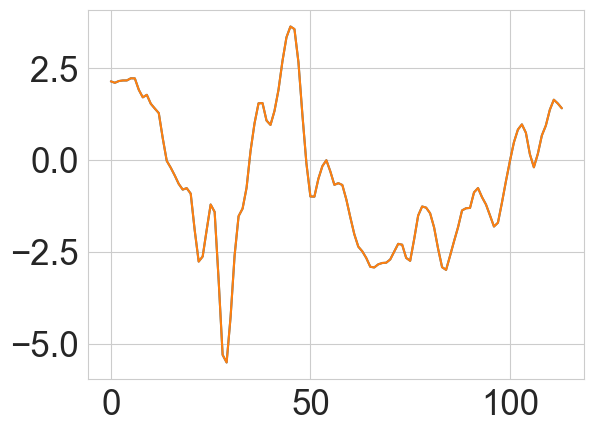

In [14]:
plt.plot(original_signal, label='original')
plt.plot(predicted_signal, label='predicted')

print(np.corrcoef(original_signal, predicted_signal)[0, 1])

In [9]:
model.coeftable['estimate'].to_numpy()

array([ 9.76756741e-01,  9.68094622e-01,  9.42066982e-01,  9.22031022e-01,
        9.17117217e-01,  9.13283291e-01,  9.02910618e-01,  8.80705568e-01,
        8.56815005e-01,  8.55208066e-01,  8.52927556e-01,  8.35072036e-01,
        8.18240365e-01,  7.92280243e-01,  7.78313872e-01,  7.79944513e-01,
        7.85879387e-01,  7.91183628e-01,  7.74261149e-01,  7.59546330e-01,
        7.65338339e-01,  7.51405201e-01,  7.05788825e-01,  6.55764213e-01,
        6.09590982e-01,  5.68971618e-01,  5.45546860e-01,  5.44016755e-01,
        5.54950854e-01,  5.46485726e-01,  5.33142444e-01,  5.27864587e-01,
        5.20887398e-01,  5.20576085e-01,  5.23504962e-01,  5.33050713e-01,
        5.60475655e-01,  5.72026523e-01,  5.56888197e-01,  5.44076166e-01,
        5.33206727e-01,  5.30148439e-01,  5.12120644e-01,  5.02786775e-01,
        5.14153255e-01,  5.22407224e-01,  5.17011880e-01,  4.94653180e-01,
        4.57355577e-01,  4.37841945e-01,  4.59797659e-01,  5.11772934e-01,
        5.42092324e-01,  

### Simple visualization

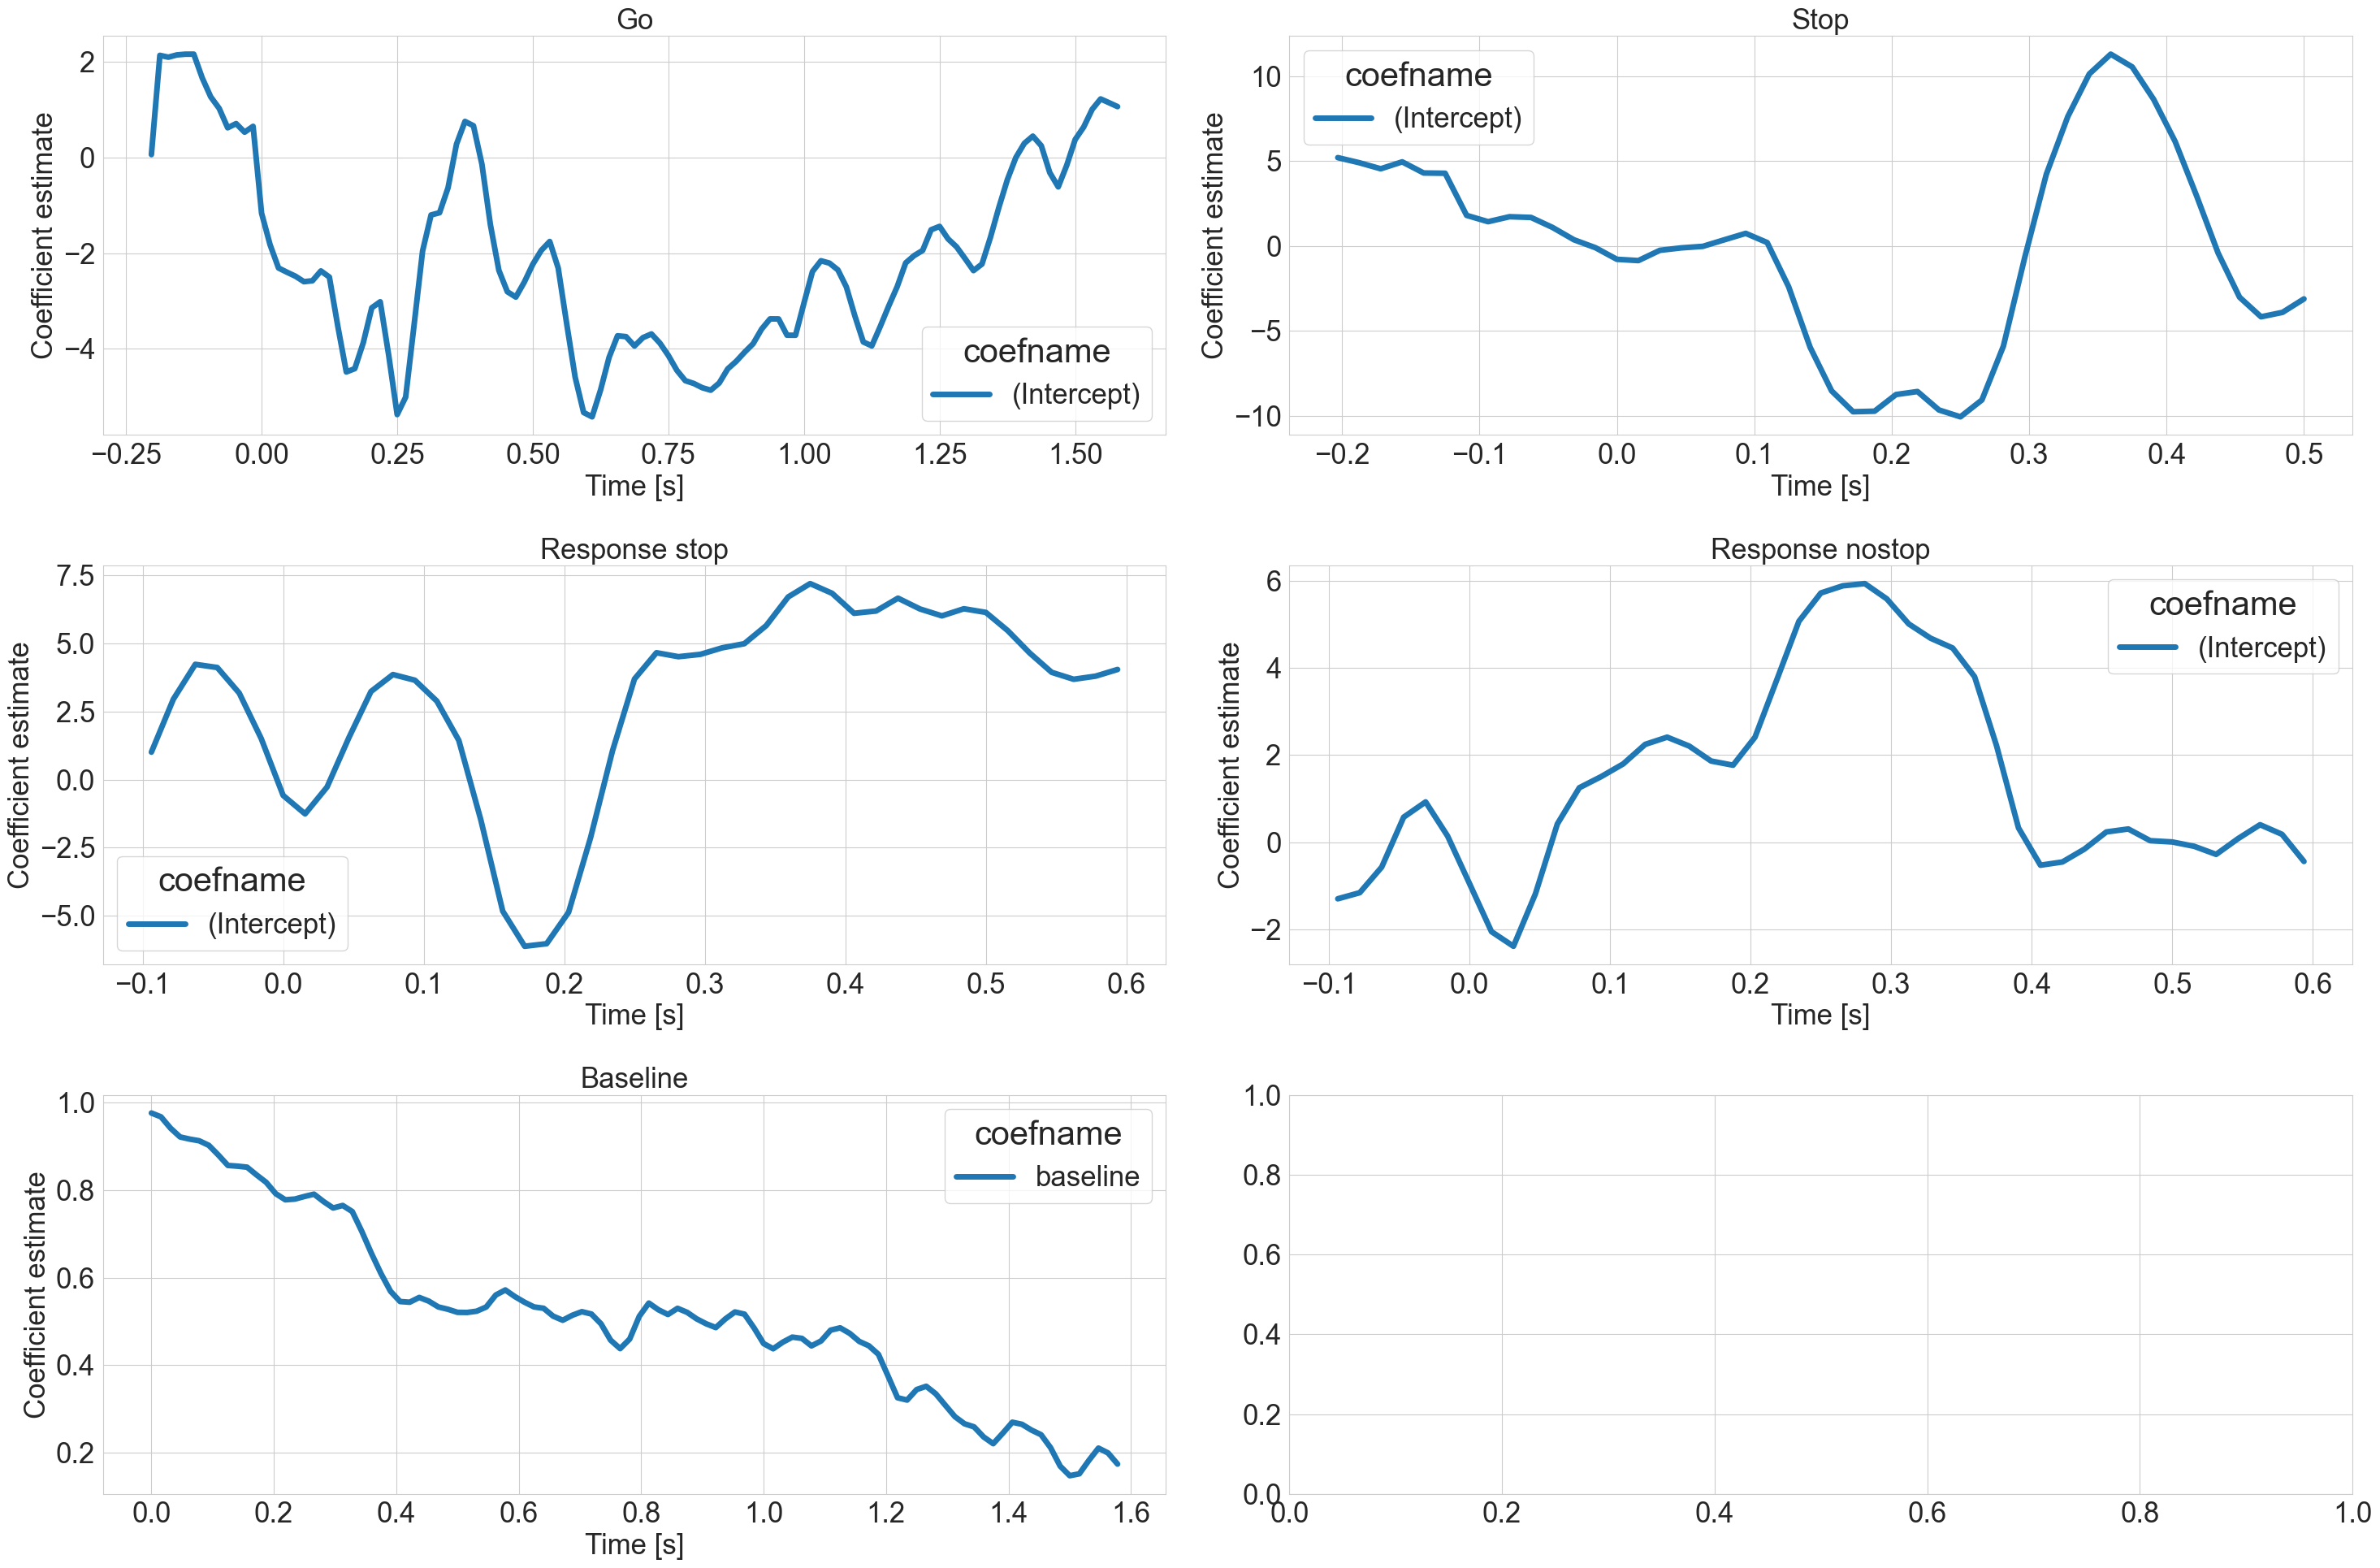

In [12]:
coef_table = model.coeftable
unfold_utils.plot_unfold_results_effects(coef_table)

0.999999997704365